In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import numpy as np

# Force CPU only
device = torch.device('cpu')

# Data transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5071,0.4865,0.4409], [0.2673,0.2564,0.2762])
])

# Load CIFAR-100 and keep only classes 0 & 1
train_ds = datasets.CIFAR100('./data', train=True, download=True, transform=transform)
test_ds  = datasets.CIFAR100('./data', train=False, download=True, transform=transform)
keep = {0,1}
train_idx = [i for i,l in enumerate(train_ds.targets) if l in keep]
test_idx  = [i for i,l in enumerate(test_ds.targets)  if l in keep]
train_ds = Subset(train_ds, train_idx)
test_ds  = Subset(test_ds,  test_idx)

print("Unique train labels:", np.unique([train_ds.dataset.targets[i] for i in train_idx]))
print("Unique test labels: ", np.unique([test_ds.dataset.targets[i]  for i in test_idx]))

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False)

# Simple 3-layer CNN
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*4*4,512), nn.ReLU(),
            nn.Linear(512,2)
        )
    def forward(self, x):
        return self.classifier(self.features(x))

model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Training
for epoch in range(10):
    model.train()
    running_loss = correct = total = 0
    for x,y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        preds = out.argmax(1)
        correct += (preds==y).sum().item()
        total   += y.size(0)
    print(f"Epoch {epoch+1} | Loss: {running_loss/len(train_loader):.4f} | Acc: {100*correct/total:.2f}%")

# Evaluation
model.eval()
correct = total = 0
with torch.no_grad():
    for x,y in test_loader:
        x, y = x.to(device), y.to(device)
        preds = model(x).argmax(1)
        correct += (preds==y).sum().item()
        total   += y.size(0)
print(f"Test Accuracy: {100*correct/total:.2f}%")

# Save the trained weights
save_path = "simple_cnn.pth"
torch.save(model.state_dict(), save_path)
print(f"Model weights saved to {save_path}")


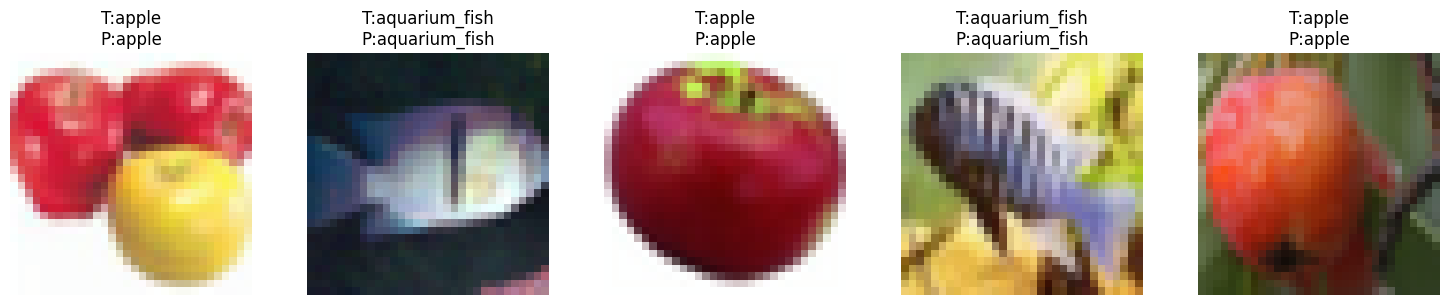

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# Define the same SimpleCNN architecture
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*4*4,512), nn.ReLU(),
            nn.Linear(512,2)
        )
    def forward(self, x):
        return self.classifier(self.features(x))

# Load the trained model
model = SimpleCNN()
model.load_state_dict(torch.load("simple_cnn.pth", map_location="cpu"))
model.eval()

# Prepare test set (classes 0 & 1 only)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5071,0.4865,0.4409], [0.2673,0.2564,0.2762])
])
full_test = datasets.CIFAR100('./data', train=False, download=True, transform=transform)
keep = {0,1}
idxs = [i for i, l in enumerate(full_test.targets) if l in keep]
test_ds = Subset(full_test, idxs)
loader = DataLoader(test_ds, batch_size=5, shuffle=True)

# Class names
class_names = full_test.classes

# Fetch one batch
images, labels = next(iter(loader))
with torch.no_grad():
    outputs = model(images)
    preds = outputs.argmax(1)

# Un-normalize and plot
mean = np.array([0.5071,0.4865,0.4409])
std  = np.array([0.2673,0.2564,0.2762])

fig, axes = plt.subplots(1, 5, figsize=(15,3))
for i in range(5):
    img = images[i].permute(1,2,0).numpy()
    img = (img * std) + mean
    img = np.clip(img, 0, 1)
    axes[i].imshow(img)
    axes[i].set_title(f"T:{class_names[labels[i]]}\nP:{class_names[preds[i]]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import numpy as np

# Define the simple CNN architecture
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*4*4,512), nn.ReLU(),
            nn.Linear(512,2)
        )
    def forward(self, x):
        return self.classifier(self.features(x))

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Data transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5071,0.4865,0.4409], [0.2673,0.2564,0.2762])
])

# Load full CIFAR100
full_train = datasets.CIFAR100('./data', train=True, download=True, transform=transform)

# Pairs to train on
pairs = [(0,1), (19,20), (39,40), (59,60), (79,80), (98,99)]

for (x, y) in pairs:
    # Filter dataset for each pair
    indices = [i for i, label in enumerate(full_train.targets) if label in {x, y}]
    subset = Subset(full_train, indices)
    loader = DataLoader(subset, batch_size=64, shuffle=True)

    # Initialize model, loss, optimizer
    model = SimpleCNN().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    # Train for 10 epochs
    for epoch in range(10):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in loader:
            # Map labels x->0, y->1 for binary classification
            labels = torch.tensor([0 if lbl == x else 1 for lbl in labels], dtype=torch.long)
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = outputs.max(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
        print(f'Pair ({x},{y}) Epoch [{epoch+1}/10] Loss: {running_loss/len(loader):.4f} Acc: {100*correct/total:.2f}%')

    # Save the model weights
    save_name = f'model_class{x}{y}.pth'
    torch.save(model.state_dict(), save_name)
    print(f'Saved weights for classes {x} and {y} as {save_name}\n')


Pair (0,1) Epoch [1/10] Loss: 0.4991 Acc: 74.50%
Pair (0,1) Epoch [2/10] Loss: 0.3731 Acc: 83.30%
Pair (0,1) Epoch [3/10] Loss: 0.2573 Acc: 89.40%
Pair (0,1) Epoch [4/10] Loss: 0.1999 Acc: 91.50%
Pair (0,1) Epoch [5/10] Loss: 0.1385 Acc: 94.80%
Pair (0,1) Epoch [6/10] Loss: 0.1145 Acc: 95.80%
Pair (0,1) Epoch [7/10] Loss: 0.0707 Acc: 97.40%
Pair (0,1) Epoch [8/10] Loss: 0.0351 Acc: 99.10%
Pair (0,1) Epoch [9/10] Loss: 0.0260 Acc: 99.30%
Pair (0,1) Epoch [10/10] Loss: 0.0233 Acc: 99.40%
Saved weights for classes 0 and 1 as model_class01.pth

Pair (19,20) Epoch [1/10] Loss: 0.4306 Acc: 79.30%
Pair (19,20) Epoch [2/10] Loss: 0.2897 Acc: 89.00%
Pair (19,20) Epoch [3/10] Loss: 0.2537 Acc: 89.60%
Pair (19,20) Epoch [4/10] Loss: 0.2086 Acc: 92.40%
Pair (19,20) Epoch [5/10] Loss: 0.1853 Acc: 92.90%
Pair (19,20) Epoch [6/10] Loss: 0.1478 Acc: 94.20%
Pair (19,20) Epoch [7/10] Loss: 0.1206 Acc: 95.00%
Pair (19,20) Epoch [8/10] Loss: 0.0936 Acc: 96.70%
Pair (19,20) Epoch [9/10] Loss: 0.0600 Acc: 9

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import numpy as np
import random
from collections import defaultdict

seed = 42  # You can replace this with any value you want

# Set the seed for random
random.seed(seed)

# Define the simple CNN architecture
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*4*4,512), nn.ReLU(),
            nn.Linear(512,num_classes)
        )
    def forward(self, x):
        return self.classifier(self.features(x))

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Data transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5071,0.4865,0.4409], [0.2673,0.2564,0.2762])
])

# Load CIFAR100
full_train = datasets.CIFAR100('./data', train=True, download=True, transform=transform)
targets = full_train.targets

# CIFAR-100 fine to coarse mapping
fine_to_coarse = [
    4, 1,14, 8, 0, 6, 7, 7,18, 3, 3,14, 9,18, 7,11, 3, 9, 7,11,
    6,11, 5,10, 7, 6,13,15, 3,15, 0,11, 1,10,12,14,16, 9,11, 5,
    5,19, 8, 8,15,13,14,17,18,10,16, 4,17, 4, 2, 0,17, 4,18,17,
   10, 3, 2,12,12,16,12, 1, 9,19, 2,10, 0, 1,16,12, 9,13,15,13,
   16,19, 2, 4, 6,19, 5, 5, 8,19,18, 1, 2,15, 6, 0,17, 8,14,13
]

# Map from coarse to list of fine labels
coarse_to_fine = defaultdict(list)
for fine, coarse in enumerate(fine_to_coarse):
    coarse_to_fine[coarse].append(fine)

# Utility: get dataset for class subset
def get_subset(class_ids):
    indices = [i for i, label in enumerate(targets) if label in class_ids]
    return Subset(full_train, indices)

# Utility: relabel to 0...N-1
def relabel(labels, class_ids):
    label_map = {cid: i for i, cid in enumerate(class_ids)}
    return torch.tensor([label_map[lbl.item()] for lbl in labels], dtype=torch.long)

# Training loop
def train_model(class_ids):
    subset = get_subset(class_ids)
    loader = DataLoader(subset, batch_size=64, shuffle=True)
    model = SimpleCNN(num_classes=len(class_ids)).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(10):
        model.train()
        correct, total, running_loss = 0, 0, 0.0
        for images, labels in loader:
            labels = relabel(labels, class_ids)
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = outputs.max(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        print(f'Classes {class_ids} Epoch [{epoch+1}/10] Loss: {running_loss/len(loader):.4f} Acc: {100*correct/total:.2f}%')

    # Save
    class_str = ''.join([str(c) for c in class_ids])
    torch.save(model.state_dict(), f'model_class{class_str}.pth')
    print(f'Saved weights as model_class{class_str}.pth\n')

# === Generate class groups ===

used = set()

# 5 binary same-coarse-class pairs
same_pairs = []
for coarse, fine_list in coarse_to_fine.items():
    if len(fine_list) >= 2:
        sampled = random.sample(fine_list, 2)
        if set(sampled).isdisjoint(used):
            same_pairs.append(sampled)
            used.update(sampled)
    if len(same_pairs) == 5:
        break

# 10 binary different-coarse-class pairs

all_groups = [
    [51, 53],
    [73, 32],
    [35, 98],
    [88, 42],
    [55, 95],
    [16, 29],
    [19, 62],
    [54, 99],
    [79, 18],
    [91, 61],
    [22, 65],
    [37, 26],
    [24, 77],
    [4, 85],
    [14, 67],
    [64, 1, 74],
    [12, 94, 9],
    [44, 3, 96],
    [58, 13, 90],
    [38, 31, 21]]
for group in all_groups:
    train_model(group)


Classes [51, 53] Epoch [1/10] Loss: 0.4108 Acc: 81.00%
Classes [51, 53] Epoch [2/10] Loss: 0.1753 Acc: 93.60%
Classes [51, 53] Epoch [3/10] Loss: 0.1390 Acc: 94.90%
Classes [51, 53] Epoch [4/10] Loss: 0.1223 Acc: 95.00%
Classes [51, 53] Epoch [5/10] Loss: 0.0980 Acc: 96.00%
Classes [51, 53] Epoch [6/10] Loss: 0.0756 Acc: 96.90%
Classes [51, 53] Epoch [7/10] Loss: 0.0518 Acc: 98.10%
Classes [51, 53] Epoch [8/10] Loss: 0.0454 Acc: 98.20%
Classes [51, 53] Epoch [9/10] Loss: 0.0431 Acc: 98.40%
Classes [51, 53] Epoch [10/10] Loss: 0.0447 Acc: 98.20%
Saved weights as model_class5153.pth

Classes [73, 32] Epoch [1/10] Loss: 0.4985 Acc: 75.20%
Classes [73, 32] Epoch [2/10] Loss: 0.3537 Acc: 85.40%
Classes [73, 32] Epoch [3/10] Loss: 0.3267 Acc: 86.90%
Classes [73, 32] Epoch [4/10] Loss: 0.2960 Acc: 87.30%
Classes [73, 32] Epoch [5/10] Loss: 0.2743 Acc: 89.80%
Classes [73, 32] Epoch [6/10] Loss: 0.2823 Acc: 89.10%
Classes [73, 32] Epoch [7/10] Loss: 0.2411 Acc: 90.70%
Classes [73, 32] Epoch [8/

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import numpy as np
import random
from collections import defaultdict

seed = 40  # You can replace this with any value you want

# Set the seed for random
random.seed(seed)

# Define the simple CNN architecture
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*4*4,512), nn.ReLU(),
            nn.Linear(512,num_classes)
        )
    def forward(self, x):
        return self.classifier(self.features(x))

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Data transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5071,0.4865,0.4409], [0.2673,0.2564,0.2762])
])

# Load CIFAR100
full_train = datasets.CIFAR100('./data', train=True, download=True, transform=transform)
targets = full_train.targets

# CIFAR-100 fine to coarse mapping
fine_to_coarse = [
    4, 1,14, 8, 0, 6, 7, 7,18, 3, 3,14, 9,18, 7,11, 3, 9, 7,11,
    6,11, 5,10, 7, 6,13,15, 3,15, 0,11, 1,10,12,14,16, 9,11, 5,
    5,19, 8, 8,15,13,14,17,18,10,16, 4,17, 4, 2, 0,17, 4,18,17,
   10, 3, 2,12,12,16,12, 1, 9,19, 2,10, 0, 1,16,12, 9,13,15,13,
   16,19, 2, 4, 6,19, 5, 5, 8,19,18, 1, 2,15, 6, 0,17, 8,14,13
]

# Map from coarse to list of fine labels
coarse_to_fine = defaultdict(list)
for fine, coarse in enumerate(fine_to_coarse):
    coarse_to_fine[coarse].append(fine)

# Utility: get dataset for class subset
def get_subset(class_ids):
    indices = [i for i, label in enumerate(targets) if label in class_ids]
    return Subset(full_train, indices)

# Utility: relabel to 0...N-1
def relabel(labels, class_ids):
    label_map = {cid: i for i, cid in enumerate(class_ids)}
    return torch.tensor([label_map[lbl.item()] for lbl in labels], dtype=torch.long)

# Training loop
def train_model(class_ids):
    subset = get_subset(class_ids)
    loader = DataLoader(subset, batch_size=64, shuffle=True)
    model = SimpleCNN(num_classes=len(class_ids)).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(10):
        model.train()
        correct, total, running_loss = 0, 0, 0.0
        for images, labels in loader:
            labels = relabel(labels, class_ids)
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = outputs.max(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        print(f'Classes {class_ids} Epoch [{epoch+1}/10] Loss: {running_loss/len(loader):.4f} Acc: {100*correct/total:.2f}%')

    # Save
    class_str = ''.join([str(c) for c in class_ids])
    torch.save(model.state_dict(), f'model_class{class_str}.pth')
    print(f'Saved weights as model_class{class_str}.pth\n')

# === Generate class groups ===

used = set()

# 5 binary same-coarse-class pairs
same_pairs = []
for coarse, fine_list in coarse_to_fine.items():
    if len(fine_list) >= 2:
        sampled = random.sample(fine_list, 2)
        if set(sampled).isdisjoint(used):
            same_pairs.append(sampled)
            used.update(sampled)
    if len(same_pairs) == 5:
        break

# 10 binary different-coarse-class pairs
diff_pairs = []
while len(diff_pairs) < 10:
    c1, c2 = random.sample(range(20), 2)
    f1, f2 = random.choice(coarse_to_fine[c1]), random.choice(coarse_to_fine[c2])
    if {f1, f2}.isdisjoint(used):
        diff_pairs.append([f1, f2])
        used.update([f1, f2])

# 3 multi-class different-coarse-class trios
diff_trios = []
while len(diff_trios) < 3:
    cs = random.sample(range(20), 3)
    trio = [random.choice(coarse_to_fine[c]) for c in cs]
    if set(trio).isdisjoint(used):
        diff_trios.append(trio)
        used.update(trio)

# 2 multi-class same-coarse-class trios
same_trios = []
for coarse, fine_list in coarse_to_fine.items():
    if len(fine_list) >= 3:
        trio = random.sample(fine_list, 3)
        if set(trio).isdisjoint(used):
            same_trios.append(trio)
            used.update(trio)
    if len(same_trios) == 2:
        break

# === Train all ===
all_groups = same_pairs + diff_pairs + diff_trios + same_trios
for group in all_groups:
    train_model(group)


Classes [57, 0] Epoch [1/10] Loss: 0.6535 Acc: 57.60%
Classes [57, 0] Epoch [2/10] Loss: 0.4993 Acc: 76.10%
Classes [57, 0] Epoch [3/10] Loss: 0.4155 Acc: 81.30%
Classes [57, 0] Epoch [4/10] Loss: 0.3540 Acc: 85.20%
Classes [57, 0] Epoch [5/10] Loss: 0.3251 Acc: 86.40%
Classes [57, 0] Epoch [6/10] Loss: 0.3151 Acc: 86.10%
Classes [57, 0] Epoch [7/10] Loss: 0.2804 Acc: 88.60%
Classes [57, 0] Epoch [8/10] Loss: 0.2134 Acc: 91.50%
Classes [57, 0] Epoch [9/10] Loss: 0.1569 Acc: 94.20%
Classes [57, 0] Epoch [10/10] Loss: 0.1415 Acc: 94.30%
Saved weights as model_class570.pth

Classes [32, 67] Epoch [1/10] Loss: 0.5812 Acc: 71.30%
Classes [32, 67] Epoch [2/10] Loss: 0.4631 Acc: 77.80%
Classes [32, 67] Epoch [3/10] Loss: 0.4130 Acc: 80.10%
Classes [32, 67] Epoch [4/10] Loss: 0.3957 Acc: 82.70%
Classes [32, 67] Epoch [5/10] Loss: 0.3794 Acc: 82.90%
Classes [32, 67] Epoch [6/10] Loss: 0.3398 Acc: 84.90%
Classes [32, 67] Epoch [7/10] Loss: 0.3237 Acc: 85.80%
Classes [32, 67] Epoch [8/10] Loss: 0

In [4]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import Subset
import numpy as np
import pickle
import os
import random
from collections import defaultdict
from sklearn.metrics import accuracy_score, precision_score, recall_score
from tqdm import tqdm

# ----------------------------
# Load CIFAR-100 fine → coarse mapping
# ----------------------------
def load_fine_to_coarse_dict(root='./data'):
    from torchvision.datasets.utils import download_and_extract_archive
    url = 'https://www.cs.toronto.edu/~kriz/cifar-100-python.tar.gz'
    filename = 'cifar-100-python.tar.gz'
    download_and_extract_archive(url, download_root=root, filename=filename)

    with open(os.path.join(root, 'cifar-100-python', 'test'), 'rb') as f:
        data = pickle.load(f, encoding='latin1')
    fine_labels = data['fine_labels']
    coarse_labels = data['coarse_labels']

    fine_to_coarse = {}
    for fine, coarse in zip(fine_labels, coarse_labels):
        fine_to_coarse[fine] = coarse
    return fine_to_coarse

fine_to_coarse = load_fine_to_coarse_dict()

# ----------------------------
# Coarse Label Names and Similarities
# ----------------------------
cifar100_coarse_labels = {
    0: "aquatic mammals", 1: "fish", 2: "flowers", 3: "food containers",
    4: "fruit and vegetables", 5: "household electrical", 6: "household furniture", 7: "insects",
    8: "large carnivores", 9: "large man-made outdoor", 10: "large natural", 11: "large omnivores",
    12: "medium mammals", 13: "non-insect invertebrates", 14: "people", 15: "reptiles",
    16: "small mammals", 17: "trees", 18: "vehicles 1", 19: "vehicles 2"
}

coarse_similarity = defaultdict(lambda: defaultdict(lambda: 0.01))
for c in cifar100_coarse_labels:
    coarse_similarity[c][c] = 0.25

similar_pairs = [
    (0, 1), (0, 12), (8, 11), (11, 12), (6, 5), (18, 19),
    (2, 17), (4, 2), (3, 5), (7, 13)
]
for a, b in similar_pairs:
    coarse_similarity[a][b] = round(random.uniform(0.04, 0.08), 3)
    coarse_similarity[b][a] = round(random.uniform(0.04, 0.08), 3)

# ----------------------------
# Model Definition
# ----------------------------
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 512), nn.ReLU(),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

# ----------------------------
# All model classes (original + new)
# ----------------------------
all_model_classes = {
    'model_class5153.pth': (51, 53),
    'model_class7332.pth': (73, 32),
    'model_class3598.pth': (35, 98),
    'model_class8842.pth': (88, 42),
    'model_class5595.pth': (55, 95),
    'model_class1629.pth': (16, 29),
    'model_class1962.pth': (19, 62),
    'model_class5499.pth': (54, 99),
    'model_class7918.pth': (79, 18),
    'model_class9161.pth': (91, 61),
    'model_class2265.pth': (22, 65),
    'model_class3726.pth': (37, 26),
    'model_class2477.pth': (24, 77),
    'model_class485.pth': (4, 85),
    'model_class1467.pth': (14, 67),
    'model_class64174.pth': (64, 1, 74),
    'model_class12949.pth': (12, 94, 9),
    'model_class44396.pth': (44, 3, 96),
    'model_class581390.pth': (58, 13, 90),
    'model_class383121.pth': (38, 31, 21),
    'model_class570.pth': (57, 0),
    'model_class3267.pth': (32, 67),
    'model_class1198.pth': (11, 98),
    'model_class4397.pth': (43, 97),
    'model_class724.pth': (72, 4),
    'model_class3651.pth': (36, 51),
    'model_class4149.pth': (41, 49),
    'model_class7183.pth': (71, 83),
    'model_class977.pth': (9, 77),
    'model_class3314.pth': (33, 14),
    'model_class4065.pth': (40, 65),
    'model_class9326.pth': (93, 26),
    'model_class3990.pth': (39, 90),
    'model_class182.pth': (18, 2),
    'model_class7652.pth': (76, 52),
    'model_class452974.pth': (45, 29, 74),
    'model_class809156.pth': (80, 91, 56),
    'model_class123042.pth': (12, 30, 42),
    'model_class208494.pth': (20, 84, 94),
    'model_class612816.pth': (61, 28, 16)
}

# ----------------------------
# Select 30 models randomly
# ----------------------------
selected_models = random.sample(list(all_model_classes.keys()), 35)
model_classes = {k: all_model_classes[k] for k in selected_models}
all_models = list(model_classes.keys())

# ----------------------------
# Build Graph with 6 Neighbors
# ----------------------------
graph = {m: set() for m in all_models}
while any(len(neighbors) < 4 for neighbors in graph.values()):
    for m in all_models:
        if len(graph[m]) < 4:
            candidates = [x for x in all_models if x != m and len(graph[x]) < 4 and x not in graph[m]]
            if candidates:
                partner = random.choice(candidates)
                graph[m].add(partner)
                graph[partner].add(m)
graph = {m: list(neighbors) for m, neighbors in graph.items()}

# ----------------------------
# Load Selected Models
# ----------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
models = {}
for model_file in model_classes:
    num_classes = len(model_classes[model_file])
    model = SimpleCNN(num_classes=num_classes).to(device)
    model.load_state_dict(torch.load(model_file, map_location=device))
    model.eval()
    models[model_file] = model

# ----------------------------
# Preprocessing
# ----------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5071, 0.4865, 0.4409], [0.2673, 0.2564, 0.2762])
])

# ----------------------------
# Score Function
# ----------------------------
def get_score(model_file, true_class):
    true_coarse = fine_to_coarse[true_class]
    total_score = 0.0
    for cls in model_classes[model_file]:
        if cls == true_class:
            total_score += 1.0
        else:
            model_coarse = fine_to_coarse[cls]
            total_score += coarse_similarity[true_coarse][model_coarse]
    return total_score / len(model_classes[model_file])

# ----------------------------
# Vote Propagation
# ----------------------------
def propagate_votes(start_model, true_class, initial_votes=10, min_votes_threshold=0.03):
    vote_counts = defaultdict(float)
    def dfs(model_file, votes):
        if votes < min_votes_threshold:
            return
        vote_counts[model_file] += votes
        neighbors = graph.get(model_file, [])
        participants = [model_file] + neighbors
        scores = {m: get_score(m, true_class) for m in participants}
        total_score = sum(scores.values())
        if total_score == 0:
            return
        for neighbor in participants:
            if scores[neighbor] > 0:
                next_votes = votes * scores[neighbor] / total_score
                dfs(neighbor, next_votes)
    dfs(start_model, initial_votes)
    return vote_counts

# ----------------------------
# Evaluation Function
# ----------------------------
def evaluate_vote_routing():
    test_data = datasets.CIFAR100('./data', train=False, download=True, transform=transform)
    test_classes = set()
    for classes in model_classes.values():
        test_classes.update(classes)

    indices = [i for i, label in enumerate(test_data.targets) if label in test_classes]
    test_subset = Subset(test_data, indices[:500])

    y_true = []
    y_pred = []
    top3_hit_count = 0
    total_models_per_run = []

    for image, true_class in tqdm(test_subset, desc="Evaluating"):
        class_votes_total = defaultdict(float)
        models_used = set()

        for _ in range(3):
            start_model = random.choice(list(model_classes.keys()))
            vote_distribution = propagate_votes(start_model, true_class)
            models_used.update(vote_distribution.keys())

            for model_file, votes in vote_distribution.items():
                model = models[model_file]
                class_set = model_classes[model_file]
                with torch.no_grad():
                    output = model(image.unsqueeze(0).to(device))
                    probs = torch.softmax(output.squeeze(0), dim=0).cpu().numpy()
                for idx, cls in enumerate(class_set):
                    class_votes_total[cls] += votes * probs[idx]

        predicted_class = max(class_votes_total.items(), key=lambda x: x[1])[0]
        top3_classes = sorted(class_votes_total.items(), key=lambda x: -x[1])[:3]
        top3_class_ids = [cls for cls, _ in top3_classes]

        y_true.append(true_class)
        y_pred.append(predicted_class)
        if true_class in top3_class_ids:
            top3_hit_count += 1
        total_models_per_run.append(len(models_used) / 3)

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
    avg_models_used_per_run = np.mean(total_models_per_run)

    print("\n=== Evaluation Summary ===")
    print(f"Samples Evaluated:               {len(test_subset)}")
    print(f"Accuracy:                        {accuracy:.4f}")
    print(f"Precision (Macro):               {precision:.4f}")
    print(f"Recall (Macro):                  {recall:.4f}")
    print(f"Top-3 Correct Classifier Hits:   {top3_hit_count}")
    print(f"Top-3 Classifier Hit Rate:       {top3_hit_count / len(test_subset):.4f}")
    print(f"Average Number of Models Used per Run: {avg_models_used_per_run:.2f}")

# ----------------------------
# Run Evaluation
# ----------------------------
results = [evaluate_vote_routing() for _ in range(5)]



Evaluating: 100%|██████████| 500/500 [01:19<00:00,  6.27it/s]



=== Evaluation Summary ===
Samples Evaluated:               500
Accuracy:                        0.5800
Precision (Macro):               0.6245
Recall (Macro):                  0.5829
Top-3 Correct Classifier Hits:   407
Top-3 Classifier Hit Rate:       0.8140
Average Number of Models Used per Run: 10.94


Evaluating: 100%|██████████| 500/500 [01:17<00:00,  6.43it/s]



=== Evaluation Summary ===
Samples Evaluated:               500
Accuracy:                        0.5420
Precision (Macro):               0.5817
Recall (Macro):                  0.5416
Top-3 Correct Classifier Hits:   398
Top-3 Classifier Hit Rate:       0.7960
Average Number of Models Used per Run: 10.92


Evaluating: 100%|██████████| 500/500 [01:16<00:00,  6.50it/s]



=== Evaluation Summary ===
Samples Evaluated:               500
Accuracy:                        0.5500
Precision (Macro):               0.5978
Recall (Macro):                  0.5489
Top-3 Correct Classifier Hits:   398
Top-3 Classifier Hit Rate:       0.7960
Average Number of Models Used per Run: 10.91


Evaluating: 100%|██████████| 500/500 [01:17<00:00,  6.48it/s]



=== Evaluation Summary ===
Samples Evaluated:               500
Accuracy:                        0.5640
Precision (Macro):               0.5947
Recall (Macro):                  0.5556
Top-3 Correct Classifier Hits:   411
Top-3 Classifier Hit Rate:       0.8220
Average Number of Models Used per Run: 10.88


Evaluating: 100%|██████████| 500/500 [01:17<00:00,  6.46it/s]


=== Evaluation Summary ===
Samples Evaluated:               500
Accuracy:                        0.5740
Precision (Macro):               0.6178
Recall (Macro):                  0.5749
Top-3 Correct Classifier Hits:   400
Top-3 Classifier Hit Rate:       0.8000
Average Number of Models Used per Run: 10.88


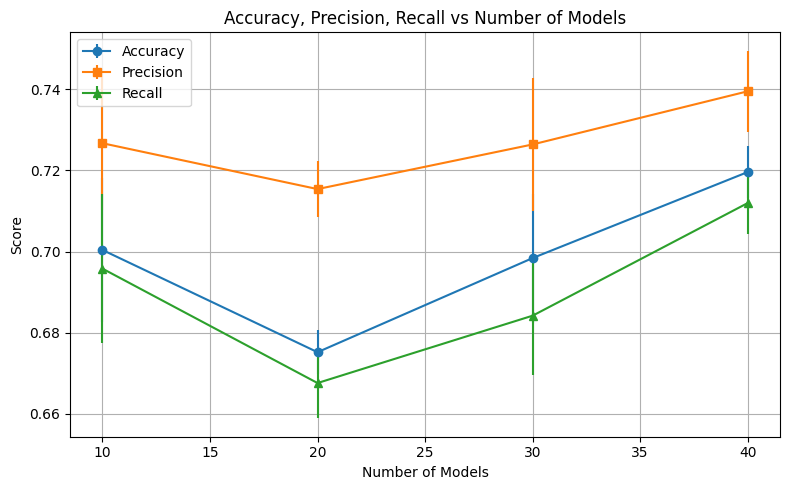

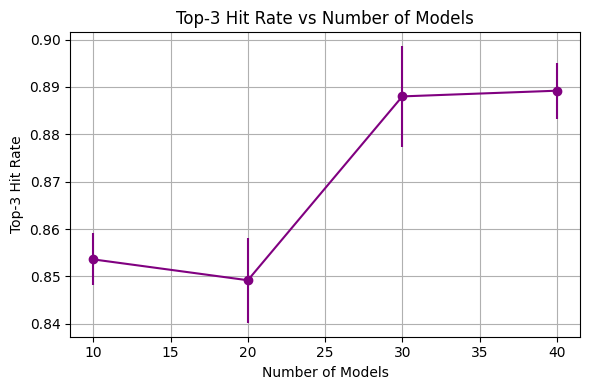

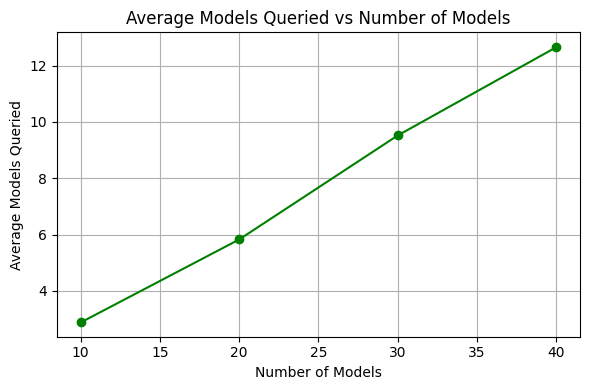

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Data
num_models = [10, 20, 30, 40]

# Metrics: (mean, std)
accuracy = [(0.7004, 0.0178), (0.6752, 0.0054), (0.6984, 0.0159), (0.7196, 0.0064)]
precision = [(0.7267, 0.0165), (0.7154, 0.0069), (0.7264, 0.0164), (0.7395, 0.01)]
recall = [(0.6958, 0.0184), (0.6676, 0.0087), (0.6842, 0.0146), (0.71196, 0.0076)]
top3_hit = [(0.8536, 0.0055), (0.8492, 0.009), (0.888, 0.0106), (0.8892, 0.0059)]
avg_models_queried = [(2.8748, 0.0146), (5.8248, 0.0221), (9.52, 0.0182), (12.656, 0.0377)]

# Helper to unpack means and stds
def unpack(metric):
    means = [m[0] for m in metric]
    stds = [m[1] for m in metric]
    return means, stds

# Plot 1: Accuracy, Precision, Recall with error bars
acc_mean, acc_std = unpack(accuracy)
prec_mean, prec_std = unpack(precision)
rec_mean, rec_std = unpack(recall)

plt.figure(figsize=(8, 5))
plt.errorbar(num_models, acc_mean, yerr=acc_std, marker='o', label='Accuracy')
plt.errorbar(num_models, prec_mean, yerr=prec_std, marker='s', label='Precision')
plt.errorbar(num_models, rec_mean, yerr=rec_std, marker='^', label='Recall')
plt.title('Accuracy, Precision, Recall vs Number of Models')
plt.xlabel('Number of Models')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 2: Top-3 Hit Rate
top3_mean, top3_std = unpack(top3_hit)

plt.figure(figsize=(6, 4))
plt.errorbar(num_models, top3_mean, yerr=top3_std, marker='o', color='purple', label='Top-3 Hit Rate')
plt.title('Top-3 Hit Rate vs Number of Models')
plt.xlabel('Number of Models')
plt.ylabel('Top-3 Hit Rate')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 3: Average Models Queried
avg_mean, avg_std = unpack(avg_models_queried)

plt.figure(figsize=(6, 4))
plt.errorbar(num_models, avg_mean, yerr=avg_std, marker='o', color='green', label='Avg Models Queried')
plt.title('Average Models Queried vs Number of Models')
plt.xlabel('Number of Models')
plt.ylabel('Average Models Queried')
plt.grid(True)
plt.tight_layout()
plt.show()
